# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Mahardika Indra Pratama Ilyasa | 5054251045 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [30]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from kagglehub import KaggleDatasetAdapter
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Dataset berhasil diunduh dari: ", path)


files = os.listdir(path)
csv_filename = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_filename)
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dataset berhasil diunduh dari:  /kaggle/input/breast-cancer-wisconsin-data


In [31]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
csv_path = "cancer.csv"
print("Ukuran dataset: ", df.shape)
print("=====5 data pertama=====")
print(df.head())
print("=====Info dataset=====")
print(df.info())
print("=====Statistik deskriptif=====")
print(df.describe())
print("=====Jumlah missing value=====")
print(df.isnull().sum())

Ukuran dataset:  (569, 33)
=====5 data pertama=====
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  te

Jumlah data per kelas:
diagnosis
B    357
M    212
Name: count, dtype: int64

Persentase per kelas (%):
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64

Rasio kelas mayoritas : minoritas = 1.68 : 1


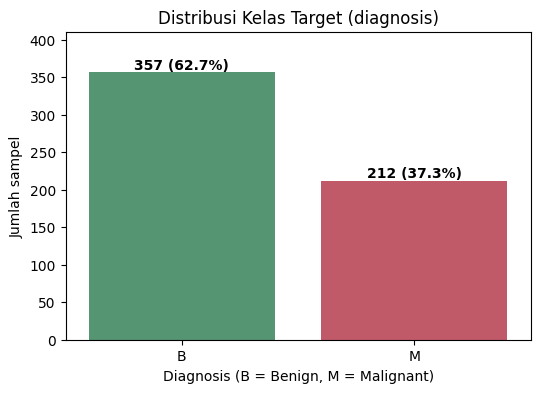


kelas B ~62.7% dan M ~37.3%. Ada ketidakseimbangan ringan (bukan imbalanced parah)


In [32]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
class_counts = df['diagnosis'].value_counts()
class_pct = df['diagnosis'].value_counts(normalize=True) * 100
print("Jumlah data per kelas:")
print(class_counts)
print("\nPersentase per kelas (%):")
print(class_pct.round(2))
print(f"\nRasio kelas mayoritas : minoritas = {class_counts.max() / class_counts.min():.2f} : 1")
palette = {'B': '#4C9F70', 'M': '#D1495B'}

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette=palette, legend=False)
for i, (label, count) in enumerate(class_counts.items()):
    ax.text(i, count + 4, f"{count} ({class_pct[label]:.1f}%)", ha='center', fontweight='bold')
ax.set_title("Distribusi Kelas Target (diagnosis)")
ax.set_xlabel("Diagnosis (B = Benign, M = Malignant)")
ax.set_ylabel("Jumlah sampel")
ax.set_ylim(0, class_counts.max() * 1.15)
plt.show()
print("\nkelas B ~62.7% dan M ~37.3%. Ada ketidakseimbangan ringan (bukan imbalanced parah)")


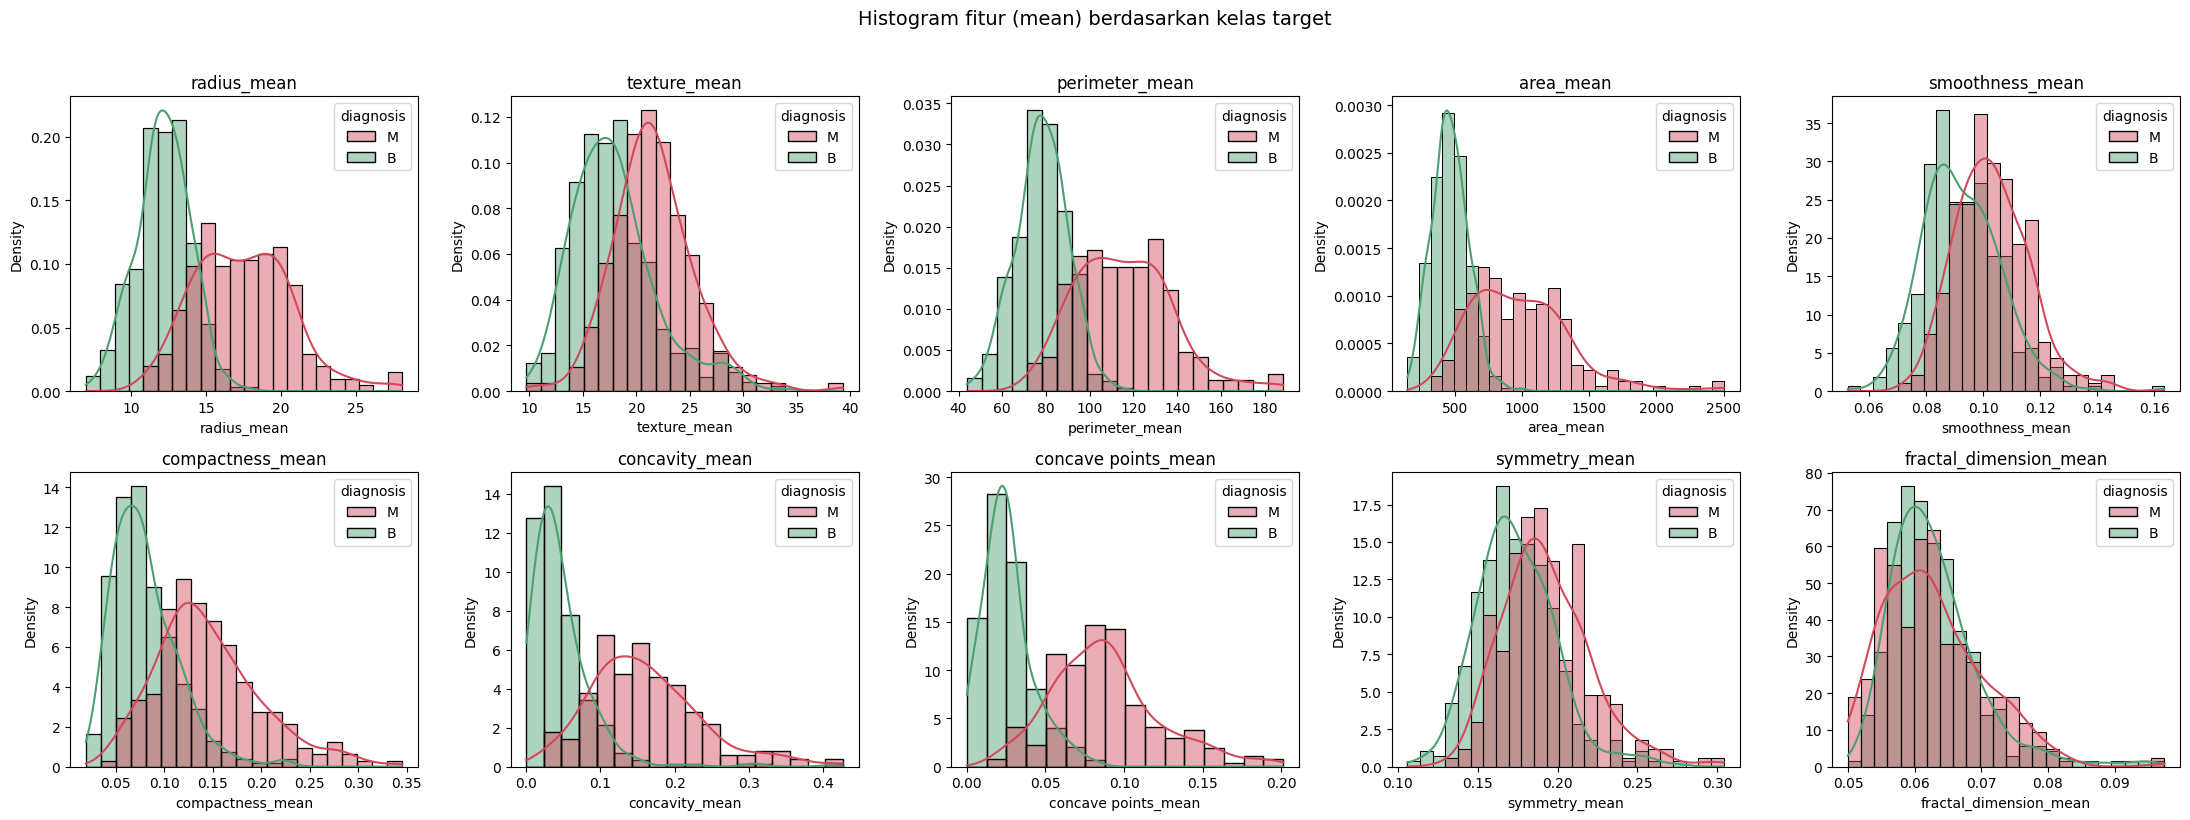

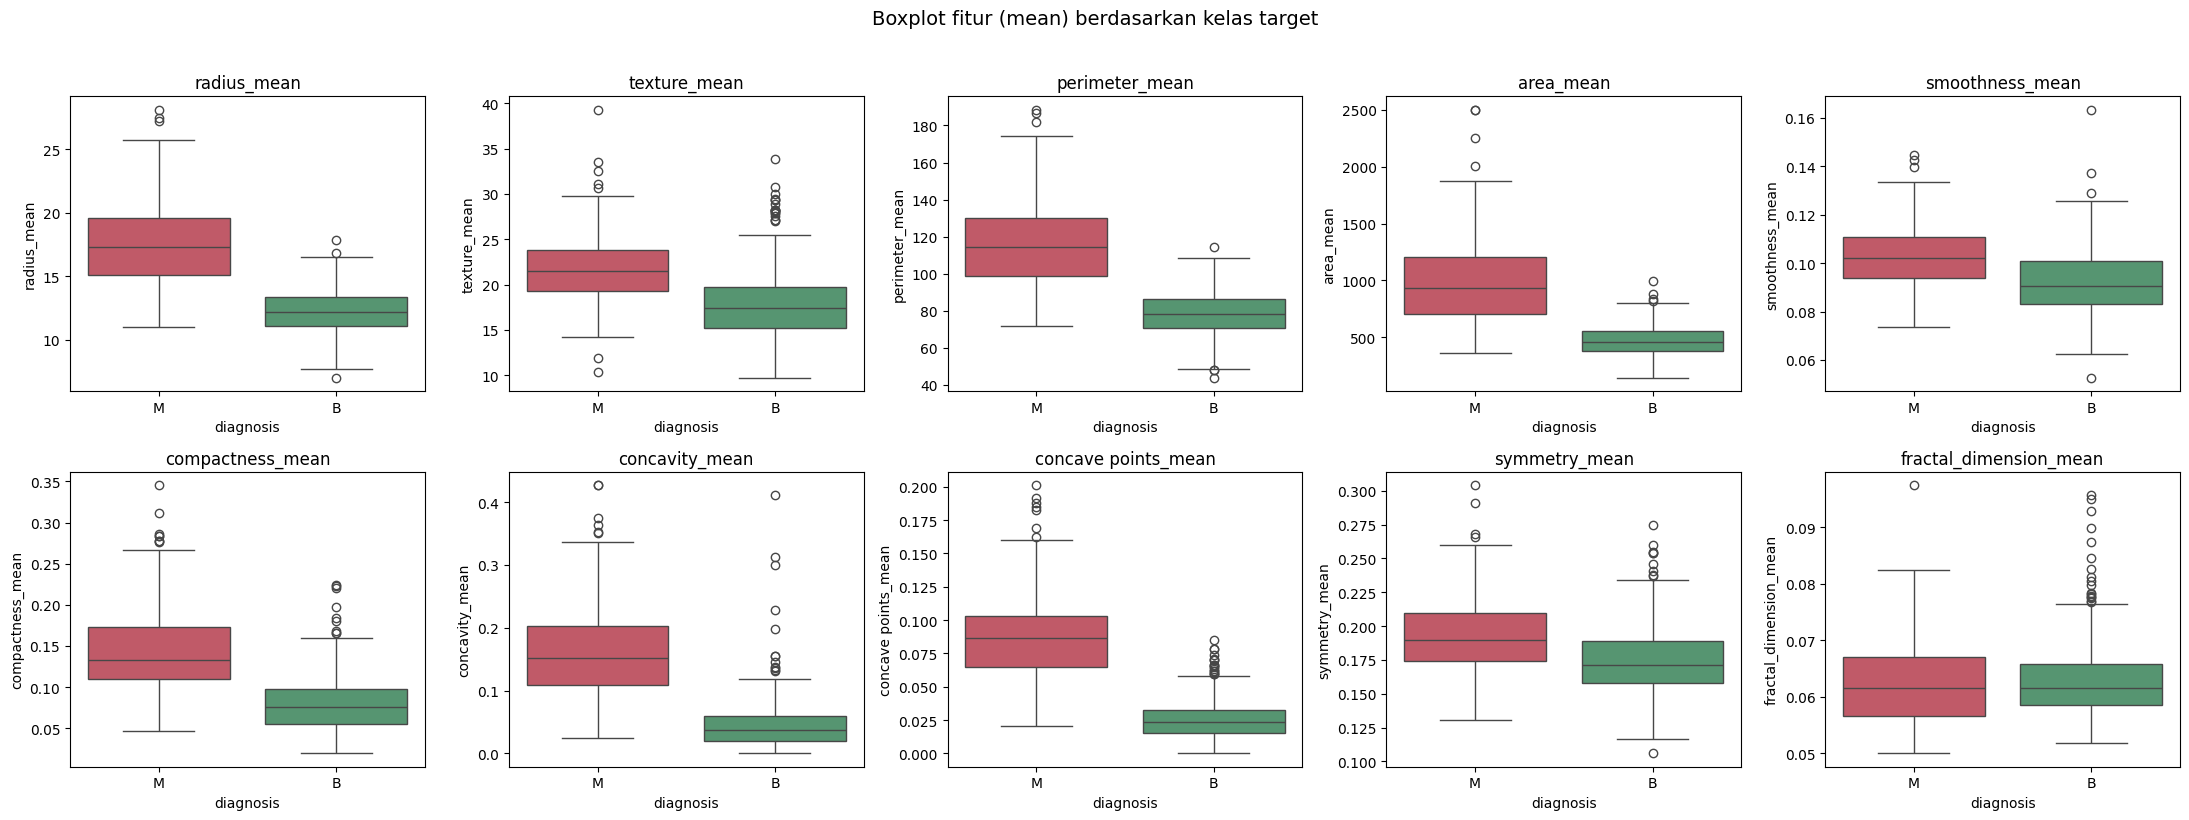

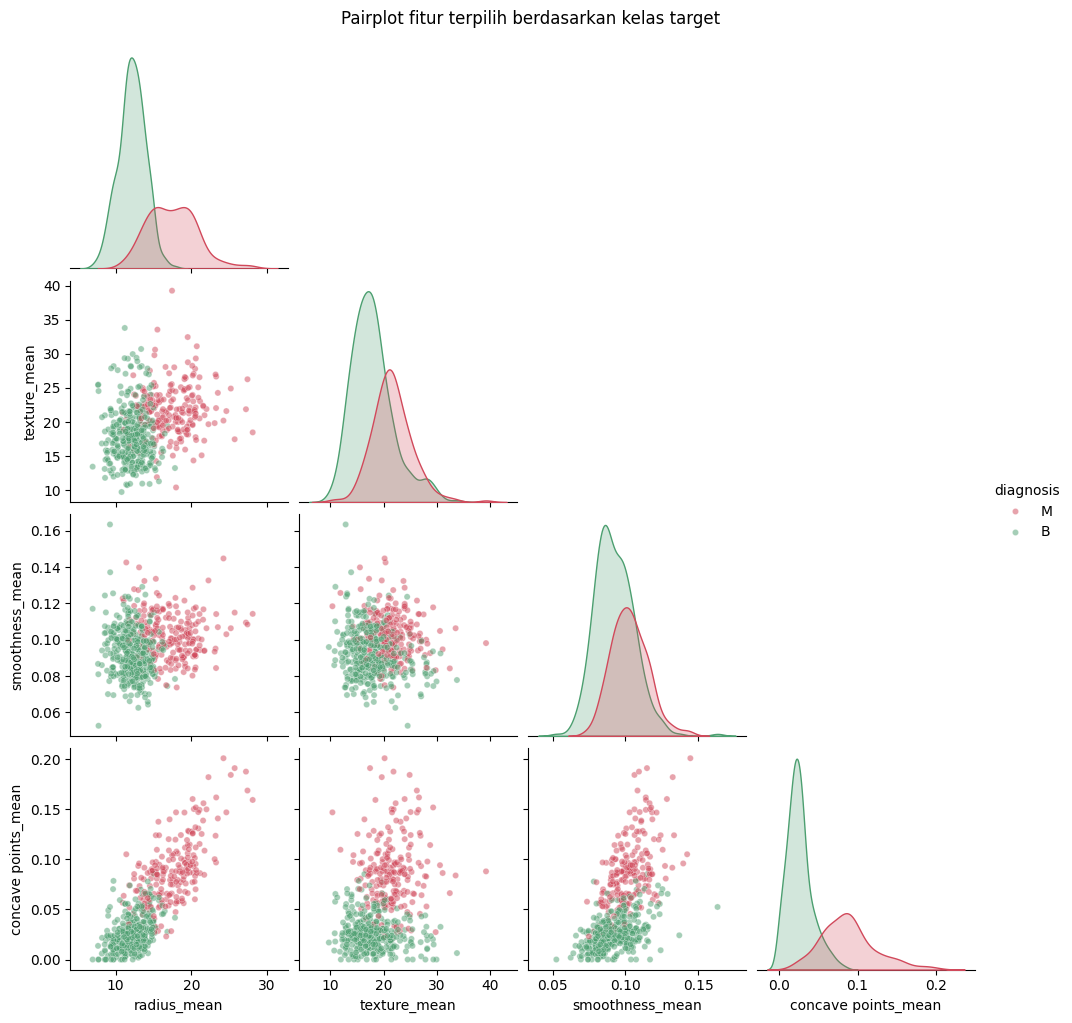

Fitur seperti smoothness, symmetry, fractal_dimension tumpang tindih hampir sepenuhnya.


In [33]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
mean_features = [c for c in df.columns if c.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.ravel(), mean_features):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, stat='density', common_norm=False,
                 palette=palette, alpha=0.45, ax=ax)
    ax.set_title(col)
plt.suptitle("Histogram fitur (mean) berdasarkan kelas target", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.ravel(), mean_features):
    sns.boxplot(data=df, x='diagnosis', y=col, hue='diagnosis', palette=palette, legend=False, ax=ax)
    ax.set_title(col)
plt.suptitle("Boxplot fitur (mean) berdasarkan kelas target", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

pair_features = ['radius_mean', 'texture_mean', 'smoothness_mean', 'concave points_mean']
sns.pairplot(df[pair_features + ['diagnosis']], hue='diagnosis', palette=palette, corner=True, plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle("Pairplot fitur terpilih berdasarkan kelas target", y=1.02)
plt.show()
print("Fitur seperti smoothness, symmetry, fractal_dimension tumpang tindih hampir sepenuhnya.")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

### Ringkasan EDA tambahan

Selain distribusi kelas dan histogram/boxplot/pairplot di atas, ditambahkan 6 analisis lanjutan. Semuanya dipilih karena berkaitan langsung dengan cara kerja SVM (sensitif terhadap skala, outlier, dan bentuk sebaran data):

| Kode | Analisis | Metode | Kenapa relevan untuk SVM |
|------|----------|--------|--------------------------|
| A | Kualitas data | `duplicated()`, `isnull().all()` | Memastikan tidak ada baris ganda dan menemukan kolom sampah (`id`, `Unnamed: 32`) sebelum modeling |
| B | Korelasi antar fitur | Heatmap korelasi Pearson + daftar pasangan `\|r\| > 0.9` | Mendeteksi multikolinearitas (fitur redundan) |
| C | Korelasi fitur dengan target | Korelasi point-biserial (Pearson fitur vs target biner) | Mengetahui fitur mana yang paling informatif untuk membedakan Benign vs Malignant |
| D | Outlier & skewness | Aturan IQR (1.5 x IQR) dan `skew()` | SVM (terutama margin & kernel RBF) bisa terpengaruh titik ekstrem |
| E | Perbedaan skala fitur | Tabel min/max/std + bar chart skala log | Bukti kuantitatif bahwa `StandardScaler` wajib dilakukan |
| F | Proyeksi PCA 2D | `StandardScaler` + `PCA(n_components=2)` | Melihat secara visual apakah kedua kelas terpisah linear atau tumpang tindih (dasar membandingkan Linear vs RBF) |

In [34]:
# Pengecekan kualitas data
feature_cols = [c for c in df.columns if c not in ['id', 'diagnosis', 'Unnamed: 32']]

print("Jumlah baris duplikat (semua kolom)  :", df.duplicated().sum())
print("Jumlah 'id' duplikat                 :", df['id'].duplicated().sum())
print("Kolom yang 100% kosong (NaN)         :", df.columns[df.isnull().all()].tolist())
print("Jumlah fitur numerik untuk modeling  :", len(feature_cols))

Jumlah baris duplikat (semua kolom)  : 0
Jumlah 'id' duplikat                 : 0
Kolom yang 100% kosong (NaN)         : ['Unnamed: 32']
Jumlah fitur numerik untuk modeling  : 30


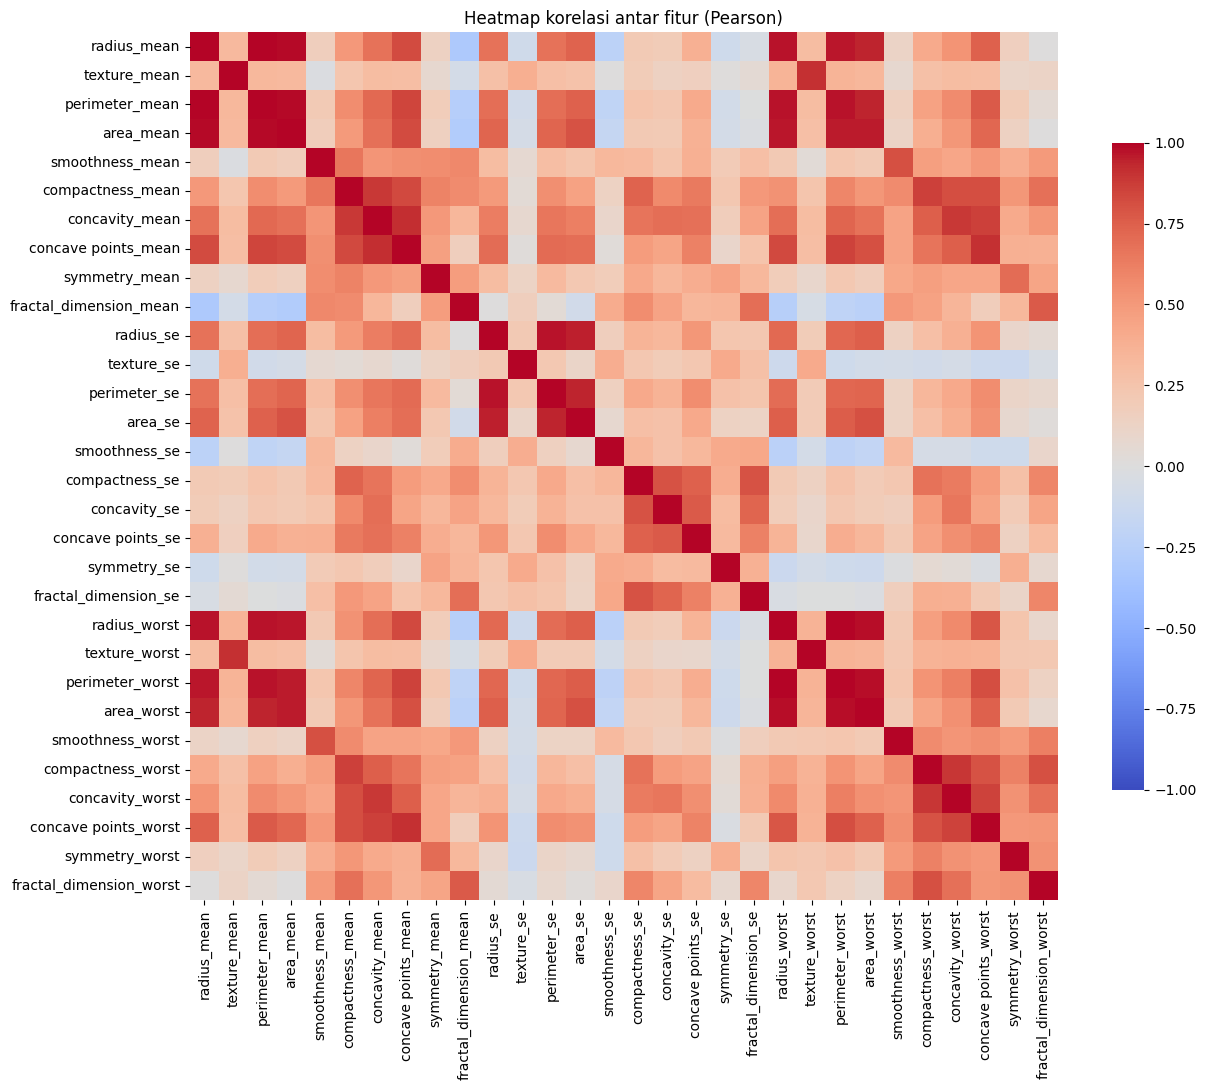

Jumlah pasangan fitur dengan |korelasi| > 0.9: 21 dari 435 pasangan
        fitur_1         fitur_2  korelasi
    radius_mean  perimeter_mean  0.997855
   radius_worst perimeter_worst  0.993708
    radius_mean       area_mean  0.987357
 perimeter_mean       area_mean  0.986507
   radius_worst      area_worst  0.984015
perimeter_worst      area_worst  0.977578
      radius_se    perimeter_se  0.972794
 perimeter_mean perimeter_worst  0.970387
    radius_mean    radius_worst  0.969539
 perimeter_mean    radius_worst  0.969476


In [35]:
# Korelasi antar fitur (heatmap) dan daftar pasangan fitur yang berkorelasi sangat tinggi
corr = df[feature_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.7})
plt.title("Heatmap korelasi antar fitur (Pearson)")
plt.show()

# Ambil segitiga atas matriks korelasi supaya tiap pasangan hanya muncul sekali
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = upper.stack().reset_index()
high_pairs.columns = ['fitur_1', 'fitur_2', 'korelasi']
high_pairs = high_pairs[high_pairs['korelasi'].abs() > 0.9].sort_values('korelasi', ascending=False)

n_pairs = len(feature_cols) * (len(feature_cols) - 1) // 2
print(f"Jumlah pasangan fitur dengan |korelasi| > 0.9: {len(high_pairs)} dari {n_pairs} pasangan")
print(high_pairs.head(10).to_string(index=False))

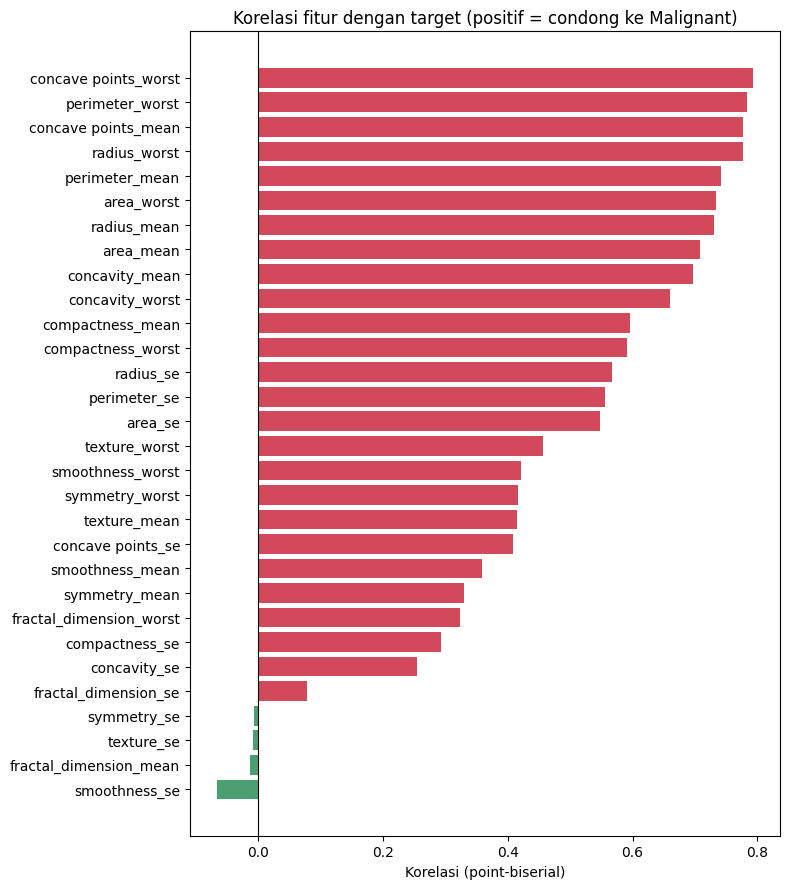

5 fitur paling berkorelasi dengan target:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
dtype: float64

5 fitur paling lemah korelasinya dengan target:
symmetry_se               0.007
texture_se                0.008
fractal_dimension_mean    0.013
smoothness_se             0.067
fractal_dimension_se      0.078
dtype: float64


In [36]:
# Korelasi tiap fitur terhadap target (target di-encode sementara: B=0, M=1 hanya untuk analisis ini)
# Pearson antara fitur numerik dan target biner
target_num = df['diagnosis'].map({'B': 0, 'M': 1})
corr_target = df[feature_cols].corrwith(target_num).sort_values()

plt.figure(figsize=(8, 9))
plt.barh(corr_target.index, corr_target.values, color=np.where(corr_target.values > 0, '#D1495B', '#4C9F70'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Korelasi fitur dengan target (positif = condong ke Malignant)")
plt.xlabel("Korelasi (point-biserial)")
plt.tight_layout()
plt.show()

print("5 fitur paling berkorelasi dengan target:")
print(corr_target.abs().sort_values(ascending=False).head(5).round(3))
print("\n5 fitur paling lemah korelasinya dengan target:")
print(corr_target.abs().sort_values().head(5).round(3))

In [37]:
# Deteksi outlier dengan aturan IQR (nilai di luar Q1 - 1.5*IQR atau Q3 + 1.5*IQR) dan skewness
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))

outlier_summary = pd.DataFrame({
    'jumlah_outlier': outlier_mask.sum(),
    'persen_outlier': (outlier_mask.mean() * 100).round(2),
    'skewness': df[feature_cols].skew().round(2)
}).sort_values('jumlah_outlier', ascending=False)

print("10 fitur dengan outlier terbanyak:")
print(outlier_summary.head(10))
print(f"\nBaris dengan minimal 1 outlier: {outlier_mask.any(axis=1).sum()} dari {len(df)}")

outlier_per_class = outlier_mask.any(axis=1).groupby(df['diagnosis']).sum()
print("\nBaris dengan outlier per kelas:")
print(outlier_per_class)
print("Outlier TIDAK dihapus: pada data medis, nilai ekstrem (mis. tumor besar) umumnya nilai asli yang \njustru informatif untuk kelas Malignant, bukan kesalahan input.")

10 fitur dengan outlier terbanyak:
                         jumlah_outlier  persen_outlier  skewness
area_se                              65           11.42      5.45
radius_se                            38            6.68      3.09
perimeter_se                         38            6.68      3.44
area_worst                           35            6.15      1.86
smoothness_se                        30            5.27      2.31
fractal_dimension_se                 28            4.92      3.92
compactness_se                       28            4.92      1.90
symmetry_se                          27            4.75      2.20
area_mean                            25            4.39      1.65
fractal_dimension_worst              24            4.22      1.66

Baris dengan minimal 1 outlier: 171 dari 569

Baris dengan outlier per kelas:
diagnosis
B     57
M    114
dtype: int64
Outlier TIDAK dihapus: pada data medis, nilai ekstrem (mis. tumor besar) umumnya nilai asli yang 
justru informatif unt

3 fitur dengan rentang terbesar dan 3 fitur dengan rentang terkecil:
                             min        max      mean       std      range
area_worst              185.2000  4254.0000  880.5831  569.3570  4068.8000
area_mean               143.5000  2501.0000  654.8891  351.9141  2357.5000
area_se                   6.8020   542.2000   40.3371   45.4910   535.3980
fractal_dimension_mean    0.0500     0.0974    0.0628    0.0071     0.0475
smoothness_se             0.0017     0.0311    0.0070    0.0030     0.0294
fractal_dimension_se      0.0009     0.0298    0.0038    0.0026     0.0289

Rasio rentang terbesar : terkecil = 140,569 : 1


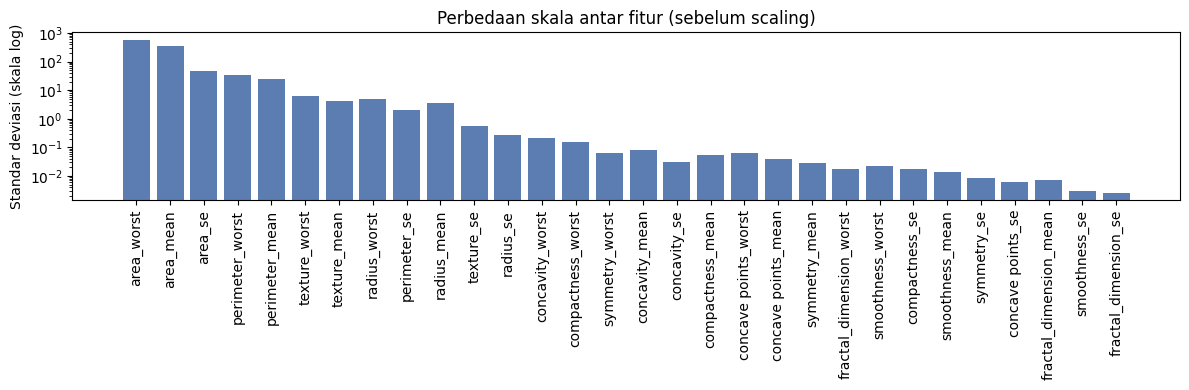

In [38]:
# Perbandingan skala (rentang nilai) antar fitur
scale_summary = df[feature_cols].agg(['min', 'max', 'mean', 'std']).T
scale_summary['range'] = scale_summary['max'] - scale_summary['min']
scale_summary = scale_summary.sort_values('range', ascending=False)

print("3 fitur dengan rentang terbesar dan 3 fitur dengan rentang terkecil:")
print(scale_summary.iloc[[0, 1, 2, -3, -2, -1]].round(4))
print(f"\nRasio rentang terbesar : terkecil = {scale_summary['range'].max() / scale_summary['range'].min():,.0f} : 1")

plt.figure(figsize=(12, 4))
plt.bar(scale_summary.index, scale_summary['std'], color='#5B7DB1')
plt.yscale('log')
plt.xticks(rotation=90)
plt.ylabel("Standar deviasi (skala log)")
plt.title("Perbedaan skala antar fitur (sebelum scaling)")
plt.tight_layout()
plt.show()

Varians yang dijelaskan PC1 & PC2: [44.27 18.97] %
Total: 63.24%


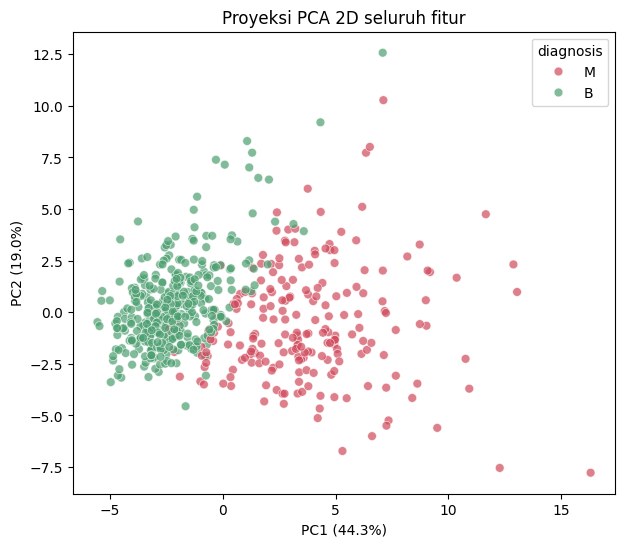

In [39]:
# Proyeksi PCA 2D  untuk melihat apakah kedua kelas terpisah secara linear
from sklearn.decomposition import PCA

# PCA sensitif terhadap skala, jadi data distandarisasi dulu.
X_eda_scaled = StandardScaler().fit_transform(df[feature_cols])
pca_eda = PCA(n_components=2, random_state=42)
X_eda_pca = pca_eda.fit_transform(X_eda_scaled)

print("Varians yang dijelaskan PC1 & PC2:", (pca_eda.explained_variance_ratio_ * 100).round(2), "%")
print(f"Total: {pca_eda.explained_variance_ratio_.sum() * 100:.2f}%")

plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_eda_pca[:, 0], y=X_eda_pca[:, 1], hue=df['diagnosis'], palette=palette, alpha=0.7, s=40)
plt.xlabel(f"PC1 ({pca_eda.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca_eda.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("Proyeksi PCA 2D seluruh fitur")
plt.show()

# 2. Preprocessing

In [40]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Cek persentase missing value tiap kolom
missing_pct = df.isnull().mean() * 100
print("Kolom dengan missing value (%):")
print(missing_pct[missing_pct > 0])

empty_cols = df.columns[df.isnull().all()].tolist()
df_clean = df.drop(columns=empty_cols).copy()
print("\nKolom yang di-drop:", empty_cols)
print("Total missing value setelah dibersihkan:", df_clean.isnull().sum().sum())
print("Ukuran data sekarang:", df_clean.shape)

Kolom dengan missing value (%):
Unnamed: 32    100.0
dtype: float64

Kolom yang di-drop: ['Unnamed: 32']
Total missing value setelah dibersihkan: 0
Ukuran data sekarang: (569, 32)


In [41]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Tidak ada fitur kategorikal; satu-satunya kolom bertipe object adalah target 'diagnosis'.
print("Kolom kategorikal:", df_clean.select_dtypes(include=['object', 'string']).columns.tolist())

df_clean['diagnosis'] = df_clean['diagnosis'].map({'B': 0, 'M': 1})
print("\nDistribusi target setelah encoding:")
print(df_clean['diagnosis'].value_counts())

Kolom kategorikal: ['diagnosis']

Distribusi target setelah encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [42]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_clean.drop(columns=['id', 'diagnosis'])
y = df_clean['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Ukuran X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Proporsi kelas Malignant -> total: {:.3f} | train: {:.3f} | test: {:.3f}".format(y.mean(), y_train.mean(), y_test.mean()))

Ukuran X_train: (455, 30) | X_test: (114, 30)
Proporsi kelas Malignant -> total: 0.373 | train: 0.374 | test: 0.368


In [43]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
# Seluruh fitur bertipe numerik, jadi semuanya di-scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Mean X_train_scaled (rata-rata semua fitur):", X_train_scaled.mean().round(4))
print("Std  X_train_scaled (rata-rata semua fitur):", X_train_scaled.std(axis=0).mean().round(4))

Mean X_train_scaled (rata-rata semua fitur): 0.0
Std  X_train_scaled (rata-rata semua fitur): 1.0


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [44]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
C_value = 1.0   # nilai C yang sama akan dipakai pada kernel RBF supaya perbandingan adil
svm_linear = SVC(kernel='linear', C=C_value, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
print("Model SVM Linear berhasil dilatih.")

Model SVM Linear berhasil dilatih.


In [45]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_scaled)
print("Contoh 10 prediksi pertama (Linear):", y_pred_linear[:10])
print("Contoh 10 label asli pertama      :", y_test.values[:10])

Contoh 10 prediksi pertama (Linear): [0 1 0 0 0 0 1 0 0 0]
Contoh 10 label asli pertama      : [0 1 0 1 0 0 1 0 0 0]


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [46]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel='rbf', C=C_value, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
print("Model SVM RBF berhasil dilatih.")

Model SVM RBF berhasil dilatih.


In [47]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svm_rbf.predict(X_test_scaled)
print("Contoh 10 prediksi pertama (RBF):", y_pred_rbf[:10])
print("Contoh 10 label asli pertama     :", y_test.values[:10])

Contoh 10 prediksi pertama (RBF): [0 1 0 0 0 0 1 0 0 0]
Contoh 10 label asli pertama     : [0 1 0 1 0 0 1 0 0 0]


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [48]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
C_values = [0.01, 0.1, 1, 10, 100]
rbf_models = {}

for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    rbf_models[c] = model
    print(f"Model RBF dengan C = {c} selesai dilatih")

Model RBF dengan C = 0.01 selesai dilatih
Model RBF dengan C = 0.1 selesai dilatih
Model RBF dengan C = 1 selesai dilatih
Model RBF dengan C = 10 selesai dilatih
Model RBF dengan C = 100 selesai dilatih


In [49]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
results_C = []
for c, model in rbf_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results_C.append({'C': c, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc,
                      'Gap (Train - Test)': train_acc - test_acc, 'Jumlah SV': model.n_support_.sum()})

results_C_df = pd.DataFrame(results_C)
print(results_C_df.round(4).to_string(index=False))

     C  Train Accuracy  Test Accuracy  Gap (Train - Test)  Jumlah SV
  0.01          0.6264         0.6316             -0.0052        341
  0.10          0.9538         0.9474              0.0065        202
  1.00          0.9868         0.9737              0.0131        107
 10.00          0.9890         0.9737              0.0153         82
100.00          1.0000         0.9649              0.0351         70


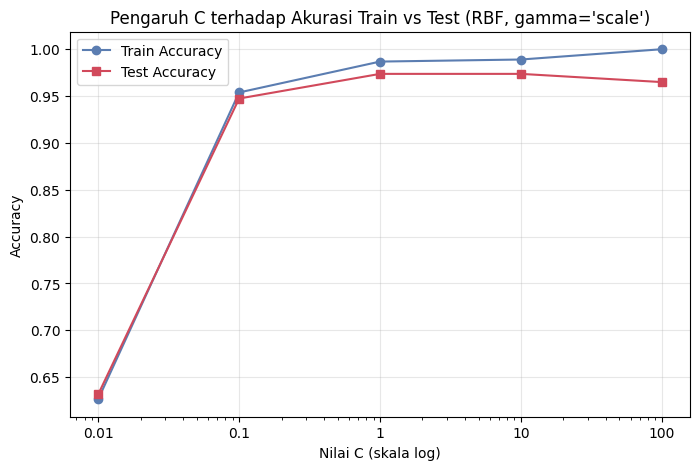


akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun


In [50]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting

plt.figure(figsize=(8, 5))
plt.semilogx(results_C_df['C'], results_C_df['Train Accuracy'], marker='o', label='Train Accuracy', color='#5B7DB1')
plt.semilogx(results_C_df['C'], results_C_df['Test Accuracy'], marker='s', label='Test Accuracy', color='#D1495B')
plt.xlabel("Nilai C (skala log)")
plt.ylabel("Accuracy")
plt.title("Pengaruh C terhadap Akurasi Train vs Test (RBF, gamma='scale')")
plt.xticks(C_values, [str(c) for c in C_values])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print("\nakurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun")

### Eksperimen tambahan: pengaruh `gamma`

Deskripsi tugas meminta variasi `C` **dan** `gamma`. Sel di bawah mengunci `C = 1` dan memvariasikan `gamma` untuk melihat sisi lain dari overfitting/underfitting pada kernel RBF.

  gamma  Train Accuracy  Test Accuracy  Gap (Train - Test)  Jumlah SV
 0.0001          0.7846         0.7719              0.0127        328
 0.0010          0.9495         0.9386              0.0109        176
 0.0100          0.9758         0.9561              0.0197         96
 0.1000          0.9890         0.9298              0.0592        194
 1.0000          1.0000         0.6316              0.3684        455
10.0000          1.0000         0.6316              0.3684        455


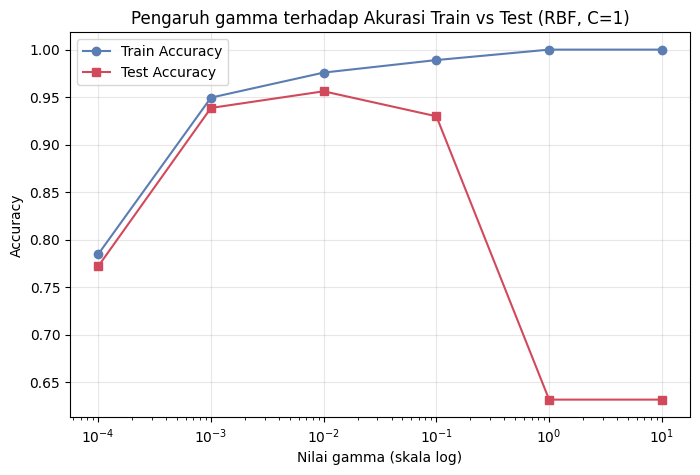

In [51]:
# Eksperimen tambahan: pengaruh gamma (C dibuat tetap = 1) terhadap akurasi train vs test pada kernel RBF
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]
results_gamma = []

for g in gamma_values:
    model = SVC(kernel='rbf', C=1, gamma=g, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results_gamma.append({'gamma': g, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc,
                          'Gap (Train - Test)': train_acc - test_acc, 'Jumlah SV': model.n_support_.sum()})

results_gamma_df = pd.DataFrame(results_gamma)
print(results_gamma_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.semilogx(results_gamma_df['gamma'], results_gamma_df['Train Accuracy'], marker='o', label='Train Accuracy', color='#5B7DB1')
plt.semilogx(results_gamma_df['gamma'], results_gamma_df['Test Accuracy'], marker='s', label='Test Accuracy', color='#D1495B')
plt.xlabel("Nilai gamma (skala log)")
plt.ylabel("Accuracy")
plt.title("Pengaruh gamma terhadap Akurasi Train vs Test (RBF, C=1)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Evaluasi Model

In [52]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def hitung_metrik(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

# Kelas positif = Malignant (1)
results_df = pd.DataFrame({
    'Linear': hitung_metrik(y_test, y_pred_linear),
    'RBF': hitung_metrik(y_test, y_pred_rbf)
}).T

print("Perbandingan metrik pada test set (C = 1):")
display(results_df.round(4))

Perbandingan metrik pada test set (C = 1):


,Accuracy,Precision,Recall,F1-Score
Linear,0.9649,1.0,0.9048,0.950
RBF,0.9737,1.0,0.9286,0.963


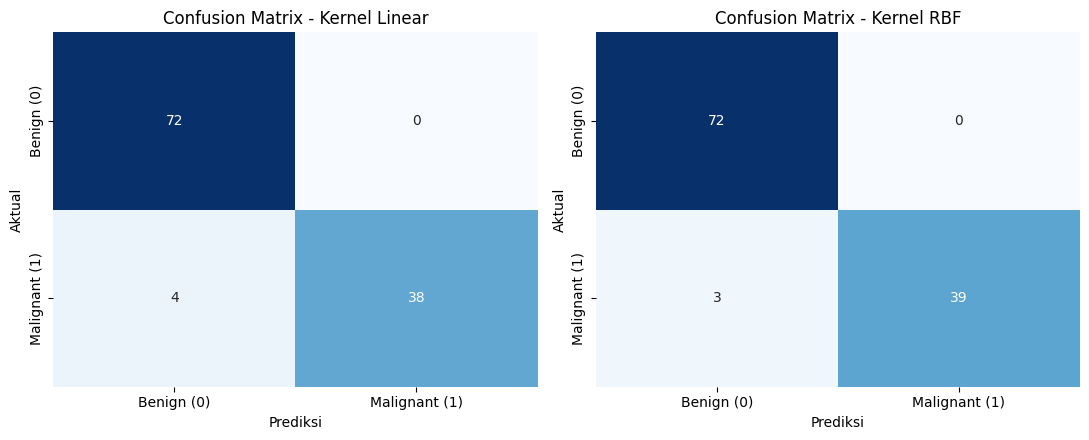

In [53]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['Benign (0)', 'Malignant (1)']

for ax, (name, y_pred) in zip(axes, [('Linear', y_pred_linear), ('RBF', y_pred_rbf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix - Kernel {name}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")

plt.tight_layout()
plt.show()

In [54]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
best_name = results_df['F1-Score'].idxmax()
models_dict = {'Linear': svm_linear, 'RBF': svm_rbf}
best_model = models_dict[best_name]
print(f"Model dengan performa terbaik: SVM kernel {best_name} (F1 = {results_df.loc[best_name, 'F1-Score']:.4f})\n")

sv_df = pd.DataFrame({
    name: {
        'SV kelas Benign (0)': m.n_support_[0],
        'SV kelas Malignant (1)': m.n_support_[1],
        'Total SV': m.n_support_.sum(),
        '% dari data latih': f"{m.n_support_.sum() / len(X_train_scaled) * 100:.2f}%"
    } for name, m in models_dict.items()
})
print("Perbandingan jumlah support vectors:")
print(sv_df)
print(f"\nBentuk array support_vectors_ model {best_name}: {best_model.support_vectors_.shape}")

Model dengan performa terbaik: SVM kernel RBF (F1 = 0.9630)

Perbandingan jumlah support vectors:
                       Linear     RBF
SV kelas Benign (0)        19      50
SV kelas Malignant (1)     19      57
Total SV                   38     107
% dari data latih       8.35%  23.52%

Bentuk array support_vectors_ model RBF: (107, 30)


Varians yang dijelaskan 2 komponen: 63.14 %
Akurasi model 2D (RBF) -> train: 0.9407 | test: 0.9298


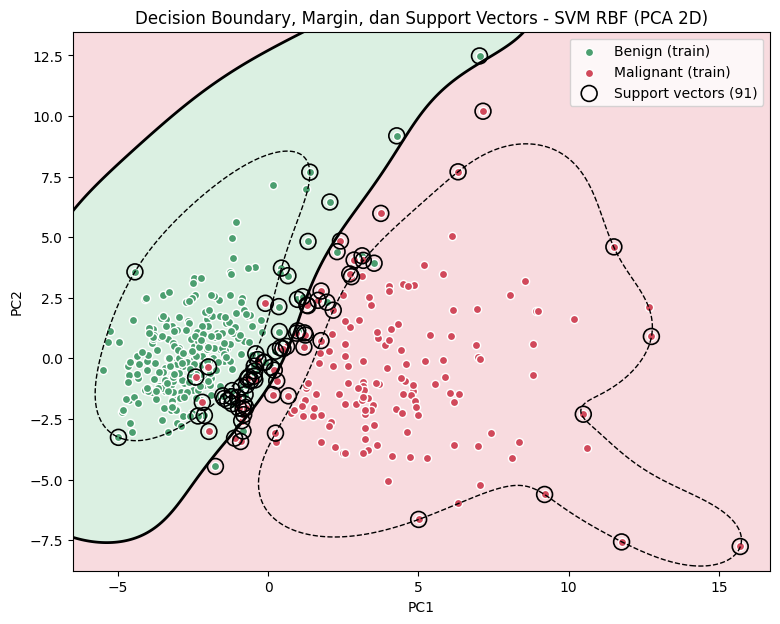

In [55]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Varians yang dijelaskan 2 komponen:", (pca.explained_variance_ratio_.sum() * 100).round(2), "%")

# Latih ulang model dengan kernel & hyperparameter yang sama seperti model terbaik, tetapi pada data 2D
svm_2d = SVC(kernel=best_model.kernel, C=best_model.C, gamma=best_model.gamma, random_state=42)
svm_2d.fit(X_train_pca, y_train)
print(f"Akurasi model 2D ({best_name}) -> train: {svm_2d.score(X_train_pca, y_train):.4f} | test: {svm_2d.score(X_test_pca, y_test):.4f}")

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], colors=['#CDEAD7', '#F6CDD2'], alpha=0.7)       # area prediksi
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'], linewidths=[1, 2, 1])  # margin & boundary
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], c=palette['B'], edgecolors='white', s=35, label='Benign (train)')
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], c=palette['M'], edgecolors='white', s=35, label='Malignant (train)')
plt.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1], s=130, facecolors='none', edgecolors='k',
            linewidths=1.2, label=f'Support vectors ({len(svm_2d.support_vectors_)})')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Decision Boundary, Margin, dan Support Vectors - SVM {best_name} (PCA 2D)")
plt.legend()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Hasil analisis berdasarkan eksperimen

> Catatan: angka di bawah berasal dari eksekusi dengan `random_state=42`, split 80:20 stratified (114 data uji: 72 Benign dan 42 Malignant). Jika Anda menjalankan ulang dan ada angka yang sedikit berbeda, sesuaikan teks ini dengan output Anda.

**1. Kernel Linear vs RBF**

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Linear (C=1) | 0.9649 | 1.0000 | 0.9048 | 0.9500 |
| RBF (C=1, gamma='scale') | 0.9737 | 1.0000 | 0.9286 | 0.9630 |

RBF sedikit lebih baik, tetapi selisihnya hanya **1 sampel** (Linear salah memprediksi 4 kasus Malignant sebagai Benign, RBF 3 kasus; keduanya 0 false positive). Dengan 114 data uji, selisih sekecil ini tidak bisa disebut signifikan. Kedua model sama-sama sangat baik.

Hal ini sesuai dengan EDA: korelasi banyak fitur terhadap target tinggi (hingga 0.79), histogram/boxplot menunjukkan fitur ukuran dan bentuk memisahkan kedua kelas dengan jelas, dan proyeksi PCA memperlihatkan kedua kelas sudah hampir terpisah linear pada ruang 30 dimensi. Pada data yang sudah hampir linear separable, bidang lurus sudah cukup, sehingga kernel non-linear hanya memberi tambahan kecil untuk menangani area tumpang tindih di perbatasan kelas.

Karena ini kasus deteksi kanker, **Recall kelas Malignant** adalah metrik yang paling penting (False Negative berarti kasus ganas lolos). Kedua model punya Precision 1.0 tetapi Recall belum sempurna, jadi masih ada kasus ganas yang terlewat.

**2. Pengaruh `C` (RBF, gamma='scale')**

| C | Train Acc | Test Acc | Gap | Jumlah SV |
|---|-----------|----------|-----|-----------|
| 0.01 | 0.6264 | 0.6316 | -0.005 | 341 |
| 0.1 | 0.9538 | 0.9474 | 0.007 | 202 |
| 1 | 0.9868 | 0.9737 | 0.013 | 107 |
| 10 | 0.9890 | 0.9737 | 0.015 | 82 |
| 100 | 1.0000 | 0.9649 | 0.035 | 70 |

- **Underfitting** terjadi pada `C = 0.01`: akurasi train dan test sama-sama rendah (~63%), sama dengan proporsi kelas Benign (62.7%). Regularisasi terlalu kuat sehingga model praktis memprediksi semuanya Benign.
- Akurasi test terbaik (0.9737) dicapai pada `C = 1` hingga `C = 10`.
- **Gejala overfitting mulai terlihat pada `C = 10` dan jelas pada `C = 100`**: akurasi train terus naik hingga 100%, sementara akurasi test berhenti naik (C = 10) lalu turun menjadi 0.9649 (C = 100). Pada grafik, ciri overfitting adalah garis train terus naik sedangkan garis test mendatar lalu turun, sehingga jarak (gap) kedua garis melebar dari 0.7% menjadi 3.5%. Dengan `C` besar, model sangat menghindari kesalahan pada data latih (margin menyempit) sehingga ikut menghafal titik ekstrem.

**3. Pengaruh `gamma` (RBF, C=1)**

| gamma | Train Acc | Test Acc | Gap | Jumlah SV |
|-------|-----------|----------|-----|-----------|
| 0.0001 | 0.7846 | 0.7719 | 0.013 | 328 |
| 0.001 | 0.9495 | 0.9386 | 0.011 | 176 |
| 0.01 | 0.9758 | 0.9561 | 0.020 | 96 |
| 0.1 | 0.9890 | 0.9298 | 0.059 | 194 |
| 1 | 1.0000 | 0.6316 | 0.368 | 455 |
| 10 | 1.0000 | 0.6316 | 0.368 | 455 |

`gamma` terlalu kecil (0.0001) menyebabkan underfitting (batas terlalu halus). `gamma` terlalu besar sangat berbahaya: pada `gamma >= 1` akurasi train 100% tetapi akurasi test jatuh ke 63.2% (hanya setara menebak kelas mayoritas) dan **seluruh 455 data latih menjadi support vector**, tanda model menghafal data tanpa bisa generalisasi. Overfitting dari `gamma` jauh lebih parah daripada dari `C`, karena `gamma` besar membuat pengaruh setiap titik sangat lokal.

**4. Jumlah support vectors**

| | Linear | RBF |
|---|--------|-----|
| SV Benign | 19 | 50 |
| SV Malignant | 19 | 57 |
| Total | 38 (8.35%) | 107 (23.52%) |

Model Linear hanya butuh 38 support vector, sedangkan RBF 107. Support vector adalah titik yang berada di margin atau salah sisi, dan hanya titik inilah yang menentukan batas keputusan. Semakin banyak support vector, semakin banyak titik yang "menarik" batas keputusan, sehingga batasnya cenderung lebih rumit/melengkung. Kernel Linear cukup dengan bidang lurus yang ditentukan sedikit titik di perbatasan, sedangkan RBF membutuhkan lebih banyak titik untuk membentuk batas non-linear. Pola yang sama terlihat pada eksperimen `gamma`: `gamma` ekstrem membuat jumlah SV melonjak sampai 455 (semua data).

**5. Visualisasi decision boundary (PCA 2D)**

Pada proyeksi 2D (63% varians), batas RBF terlihat melengkung mengikuti sebaran kelas dan sejumlah support vector berada di area tumpang tindih. Akurasi model 2D (test 0.9298) lebih rendah dari model 30 fitur (0.9737) karena sekitar 37% informasi hilang saat reduksi, jadi plot ini hanya ilustrasi, bukan pengganti model sebenarnya.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

1. SVM dengan kernel Linear maupun RBF sama-sama bekerja sangat baik pada dataset Breast Cancer Wisconsin (akurasi 96.5% dan 97.4%). RBF sedikit lebih unggul (F1 0.963 vs 0.950), namun selisihnya hanya satu sampel uji sehingga belum dapat disimpulkan signifikan. Hal ini konsisten dengan EDA yang menunjukkan data hampir terpisah linear.
2. Feature scaling sangat penting karena rasio rentang antar fitur mencapai lebih dari 140.000 : 1. Scaler hanya di-fit pada train set untuk menghindari data leakage.
3. `C` terlalu kecil menyebabkan underfitting (C = 0.01, akurasi ~63%), sedangkan `C` terlalu besar menyebabkan overfitting (C = 100: train 100%, test turun ke 96.5%). Nilai `C` sekitar 1 sampai 10 memberi keseimbangan terbaik.
4. `gamma` sangat sensitif: `gamma` besar (>= 1) membuat model menghafal data latih (train 100%, test 63.2%, seluruh data menjadi support vector), sedangkan `gamma` kecil menyebabkan underfitting.
5. Model Linear memakai lebih sedikit support vector (38) dibanding RBF (107) sehingga lebih sederhana, dan pada dataset ini performanya hampir sama baiknya.

**Saran:**
- Lakukan hyperparameter tuning `C` dan `gamma` secara bersamaan dengan `GridSearchCV` dan stratified k-fold cross-validation, karena evaluasi pada satu split dengan 114 data uji sangat rentan terhadap selisih 1-2 sampel.
- Untuk kasus medis, utamakan peningkatan **Recall** kelas Malignant (mis. `class_weight='balanced'` atau mengatur threshold keputusan) karena False Negative lebih berbahaya.
- Coba kernel Polynomial, seleksi fitur (membuang fitur yang redundan/tidak informatif berdasarkan EDA B dan C), serta bandingkan dengan model lain seperti Logistic Regression atau Random Forest.